# 06a - Strategy 1: Inventory-Led Model Transition
### Tested with Reinforcement Learning (PPO)

> **⚠ Real-data refresh (inputs updated).** The environment's inputs were re-anchored to validated public
> data: baseline density **1,093** (Q4 FY26, was 1,025/Q2), the inventory benefit **~100 bps** (Blinkit's
> observed EBITDA accretion, the proxy for Instamart's potential — Swiggy never transitioned), and 06c's
> store cost now ~Rs 1 cr. The **result figures in the interpretation cells below** (cumulative
> contribution, breakeven quarter, the distilled decision rules, the capex tornado) reflect the *prior*
> run; they refresh — and should move up, since the inventory lever is now larger and Instamart starts
> closer to breakeven — when the notebook is **re-executed**.

**Where this sits in the case study**

Notebooks 01-05 *diagnosed* why Instamart's path to profitability lags Blinkit. Notebook 06
*tests the cures*. This is the first of three strategy simulations:

- **06a (this notebook)** - Should Swiggy transition Instamart to Blinkit's inventory-led model, and if so, how fast? -> Reinforcement Learning
- **06b** - Should Swiggy cross-sell its 18.3M food-delivery users into Instamart? -> Uplift modeling + Monte Carlo
- **06c** - Should Swiggy hold store expansion and grow density first? -> System Dynamics + deep-uncertainty analysis
- **06d** - How do the three strategies compare and sequence?

**The question this notebook answers**

Branch 4 (logistics) found that 90% of Blinkit's NOV runs through an inventory-led model worth a
disclosed **~100 bps** of EBITDA accretion (Eternal CFO; ~300 bps gross-margin lift), and that Swiggy's
own shareholder vote to adopt the same model *failed by 2.65 pp* (72.35% vs. the 75% needed) - so Swiggy
has *not* transitioned, and this benefit is Blinkit's observed figure used as Instamart's proxy. The
lever exists and is proven by a competitor. The open question is one of **pace and sequencing**: if Swiggy did get to transition,
how aggressively should it push the inventory-led share each quarter, given that the transition
costs capex, and that same capex is also what funds the density growth that drives the *larger*
share of the margin gap?

That is a sequential decision problem under a budget constraint - exactly what reinforcement
learning is for. We frame it as a Markov Decision Process, build a simulation environment
calibrated to disclosed figures, and train a PPO agent to learn the optimal transition policy.

**Honesty flag up front (read before trusting any number below)**

Every economic coefficient in this environment is now tied to a disclosed or derived source:

- the **inventory lever** is **~100 bps** - Blinkit's *observed* EBITDA accretion (Eternal CFO: ~100 bps
  + ~300 bps gross margin), used as the proxy for what Instamart *could* gain, since Swiggy never
  transitioned (the IOCC vote failed). It is *not* an inflated assumption;
- the **density lever** is the slope regressed from Notebook 02's *simulated* n=1,143 store network
  (~0.0000794 margin per order/day; the real-data breakeven is ~1,225-1,300 per Redseer, and the env
  anchors at the disclosed (1,093, -1.8%) point), which is far larger than the inventory lever -
  consistent with the case-study thesis that **density, not the inventory model, is the dominant driver**;
- the **capex war chest** starts from the disclosed Rs 4,475 cr QIP earmark and flexes with the
  disclosed Rs 5,675 cr NOV.

What remains an estimate (flagged inline): the Rs 80 cr-per-5pp transition cost, the cost of buying a
unit of density, the quarterly densification budget, and the competitive-drag coefficient. The right
way to read the output is *"this is the methodology for finding the optimal transition pace once you
have real store-level data"* - not *"Swiggy should push inventory-led share by exactly X pp in quarter 3."*


In [1]:

# If running for the first time, install the RL dependencies:
# pip install "gymnasium>=0.29" "stable-baselines3>=2.3"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, Optional

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.logger import configure
import os
import torch
import gc

# --- Resource caps so training never hoards your laptop ---
# Cap CPU threads (your Ryzen 5 4600H has 6 cores / 12 threads; leave headroom for other work).
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
torch.set_num_threads(4)
torch.backends.cudnn.benchmark = False

# --- Device choice: CPU is the RIGHT call here, and here's why ---
# PPO with a small MlpPolicy does tiny matrix multiplies. On a GTX 1650 the cost of moving
# each minibatch CPU<->GPU outweighs the compute saving, and the environment stepping (which
# dominates wall-clock here) runs on CPU regardless. SB3's own docs note PPO/A2C with MLP
# policies are usually FASTER on CPU. GPU only helps SB3 for CnnPolicy on image observations.
# We still detect CUDA (so you can flip USE_GPU=True to experiment), but default to CPU.
USE_GPU = False
device = "cuda" if (USE_GPU and torch.cuda.is_available()) else "cpu"
print(f"Torch sees CUDA: {torch.cuda.is_available()}"
      + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))
print(f"Training device: {device}  (MLP-PPO is intentionally on CPU - see comment above)")
if device == "cuda":
    torch.cuda.empty_cache()

PROCESSED = Path("../data/processed")
MODELS = Path("../models/strategy1")
MODELS.mkdir(parents=True, exist_ok=True)

RNG_SEED = 42
np.random.seed(RNG_SEED)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Brand palette, consistent with the rest of the case study / deck
SWIGGY = "#FC8019"; BLINKIT = "#0C9D61"; ZEPTO = "#8025FB"; NAVY = "#1B2A4A"


Torch sees CUDA: False
Training device: cpu  (MLP-PPO is intentionally on CPU - see comment above)


## 2.0 Calibrated Baseline

Every constant below is pulled from `master_metrics.csv` (Notebook 01) or regressed live from the
simulated store network (Notebook 02). Confidence tags: **D** = company-disclosed,
**E** = analyst-estimated, **DV** = derived. Items tagged E are assumptions the policy rests on,
flagged inline.

> **The two margin levers, and which one actually matters.** The inventory-model lever is **~100 bps**
> (`inv_total_bps`, master row 85) - Blinkit's *observed* EBITDA accretion (Eternal CFO), the proxy for
> Instamart's potential, since Swiggy never transitioned. The density lever is the slope of contribution
> margin on orders/store/day, regressed live from Notebook 02's n=1,143 simulated network
> (`density_margin_slope`). That slope implies climbing from today's ~1,093 toward the ~2,000 capacity
> ceiling is worth **~7-8 percentage points** of margin - several times the inventory model. This is deliberate: it encodes the
> case-study's central finding that **density/maturity is the core economic variable and the
> inventory model is a secondary lever**. Earlier drafts inverted this by assigning the inventory
> model a 240 bps effect with no individual source; that has been removed.

> **What is still an estimate (flag these in a walkthrough):** `capex_per_5pp_cr` (transition cost),
> `capex_per_density_cr` (rupees to buy a unit of density), `density_budget_cr` (quarterly
> densification spend), and `drag_k` (competitive-drag strength). Section 8 sweeps the reward
> weights; a real engagement would also stress these four.

In [2]:

# Load the disclosed figures straight from Notebook 01's output so this notebook
# never hard-codes a number that already lives in the master table.
master = pd.read_csv(PROCESSED / "master_metrics.csv")

def lookup(company, metric, default=None, period=None):
    '''Fetch a value from master_metrics; optionally pin a period to avoid ambiguity.'''
    q = (master.company == company) & (master.metric == metric)
    if period is not None:
        q &= (master.period == period)
    hit = master[q]
    return float(hit["value"].iloc[0]) if len(hit) else default

# --- Density -> margin relationship, regressed LIVE from Notebook 02's simulated network ---
# This makes the density coefficient genuinely "calibrated to the n=1,143 sim" rather than a
# hand-picked number. The synthetic regression's own x-intercept is ~1,552 (higher than the real-data
# breakeven of ~1,225-1,300 per Redseer); the RL env anchors at the disclosed (1,093, -1.8%) point and the
# regression SLOPE (~7.9e-5), which puts the env's *effective* breakeven near ~1,320 - consistent with 06c.
proxy = pd.read_csv(PROCESSED / "b1_instamart_simulated_store_level_PROXY.csv")
_slope_pp, _intercept_pp = np.polyfit(proxy["orders_per_day"], proxy["contribution_margin_pct"], 1)
_r2 = np.corrcoef(proxy["orders_per_day"], proxy["contribution_margin_pct"])[0, 1] ** 2
DENSITY_MARGIN_SLOPE = _slope_pp / 100.0          # pp/order -> margin-fraction per order/day
BREAKEVEN_DENSITY    = -_intercept_pp / _slope_pp  # orders/day where the sim's margin crosses 0
print(f"Notebook 02 regression  ->  slope={DENSITY_MARGIN_SLOPE:.8f} /order/day, "
      f"breakeven={BREAKEVEN_DENSITY:.0f} orders/day, R^2={_r2:.3f}")

BASELINE = {
    # -- Swiggy Instamart (starting state) -------------------------------------------------
    "avg_density":            lookup("Swiggy Instamart", "Orders per Store per Day", 1093, period="Q4FY26"),  # D - Q4 FY26 (1,025 was Q2 FY26)
    "density_ceiling":        2000,                                                                  # D  - Swiggy stated 2,000+ capacity ceiling
    "breakeven_density":      round(BREAKEVEN_DENSITY, 1),                                           # DV - regressed above (Notebook 02)
    "density_margin_slope":   DENSITY_MARGIN_SLOPE,                                                  # DV - regressed above (Notebook 02)
    "contribution_margin":    lookup("Swiggy Instamart", "Contribution Margin", -1.8,
                                     period="Q4FY26") / 100.0,                                       # D  - Q4 FY26
    "market_share":           lookup("Swiggy Instamart", "Market Share", 24.0) / 100.0,             # E  - S23 (Datum/Reuters, Jan 2026)
    "pct_inventory_led":      0.10,                                                                  # E  - Swiggy is marketplace-led; ~10% inventory (not separately disclosed)
    "nov_cr":                 lookup("Swiggy Instamart", "NOV", 5675, period="Q4FY26"),             # D  - Q4 FY26, drives operating cash flow
    "capex_reserve_cr":       lookup("Swiggy Instamart", "Capex Allocated from QIP", 4475),         # D  - QIP earmark, the transition war chest
    # -- Blinkit reference figures ---------------------------------------------------------
    "blinkit_density":        lookup("Blinkit", "Orders per Store per Day", 1425),                   # DV - Q4 FY26, derived from Eternal letter
    "blinkit_market_share":   lookup("Blinkit", "Market Share", 46.0) / 100.0,                       # E  - S23
    "blinkit_inventory_led":  lookup("Blinkit", "Inventory-led NOV Share", 90.0) / 100.0,            # D  - the 90% transition ceiling
    "margin_cap":             lookup("Blinkit", "Mature Market EBITDA Margin (Gurgaon/Noida)",
                                     5.0) / 100.0,                                                   # D  - realistic upper bound on margin (Blinkit's best mature market)
    # -- Inventory model economics ---------------------------------------------------------
    "inv_total_bps":          lookup("Blinkit",
                                     "Inventory Model Margin Benefit (EBITDA accretion)", 100.0),     # D  - Blinkit's OBSERVED ~100bps EBITDA accretion (Eternal CFO); the proxy for Instamart's potential. Swiggy never transitioned (IOCC vote failed), so this is NOT a Swiggy disclosure
    # -- Flagged ESTIMATES (no individual public source) -----------------------------------
    "capex_per_5pp_cr":       80.0,    # E - Rs 80 cr to move inventory-led share +5 pp (transition cost still unsourced)
    "capex_per_density_cr":   4.0,     # E - Rs cr to lift network-avg density by 1 order/store/day (cf. 06c's ~Rs 1cr/store)
    "density_budget_cr":      300.0,   # E - max capex deployed to densification per quarter
    "drag_k":                 0.003,   # E - competitive-drag strength (margin pp per pp of share gap vs Blinkit)
}

for k, v in BASELINE.items():
    print(f"  {k:24s} = {v}")


Notebook 02 regression  ->  slope=0.00007942 /order/day, breakeven=1552 orders/day, R^2=0.409
  avg_density              = 1093.0
  density_ceiling          = 2000
  breakeven_density        = 1552.1
  density_margin_slope     = 7.941781072769039e-05
  contribution_margin      = -0.018000000000000002
  market_share             = 0.24
  pct_inventory_led        = 0.1
  nov_cr                   = 5675.0
  capex_reserve_cr         = 4475.0
  blinkit_density          = 1425.0
  blinkit_market_share     = 0.46
  blinkit_inventory_led    = 0.9
  margin_cap               = 0.05
  inv_total_bps            = 100.0
  capex_per_5pp_cr         = 80.0
  capex_per_density_cr     = 4.0
  density_budget_cr        = 300.0
  drag_k                   = 0.003


## 3.0 Environment Design - State, Action, Reward

**State (6 continuous variables).** Everything the decision-maker can observe each quarter. The
values are *scaled* to a common O(1) range before they reach the network (margin x10, quarter/12)
so no single component dominates the input by magnitude - without this, an ~0.01-scale margin next
to a 0-12 quarter starves the policy of a usable gradient.

| Variable | Scaled range | Meaning |
|---|---|---|
| `density_norm` | 0-1 | orders/store/day / ceiling |
| `pct_inventory_led` | 0-0.9 | share of NOV running through the inventory model |
| `margin x10` | -1.0 to +0.5 | fractional contribution margin, scaled |
| `market_share` | 0-1 | share of the quick-commerce market |
| `capex_norm` | 0-3 | capex war chest / its starting value |
| `quarter/12` | 0-1 | three-year horizon, scaled |

**Action (Discrete, 5 choices).** How hard to push the inventory transition this quarter:

| Action | Effect on inventory-led share |
|---|---|
| 0 - Hold | no change |
| 1 - Slow push | +5 pp |
| 2 - Moderate push | +10 pp |
| 3 - Aggressive push | +15 pp |
| 4 - Retreat | -5 pp (de-risk if capex is tight) |

Discrete (not continuous) on purpose: the learned policy reads as a sentence - *"in quarter 3 the
agent chooses Moderate push"* - which is far easier to defend in an interview than a continuous
control signal.

**Reward.** A weighted blend of the three things a quick-commerce operator actually cares about:
margin (50%), competitive position (30%), and capex sustainability (20%). The weights are a
modelling choice; Section 8 re-runs training across different weightings to show how sensitive the
policy is to them.

**Episode.** 12 quarters. Terminates early on **capex insolvency** - if the war chest is exhausted
before the business reaches profitability, the strategy has failed. Unlike the previous margin-based
rule (which the margin dynamics could never actually reach), this stop is reachable, so it teaches
the agent that pushing the transition so hard it burns the war chest is not free.

## 4.0 Custom Gym Environment

The `step()` method encodes the causal model. Read the inline comments as the assumptions ledger -
each relationship is either disclosed, regressed from a disclosed/simulated figure, or an explicit
estimate.

**Key causal relationships modelled:**
1. `pct_inventory_led` up -> margin up, capped at the disclosed **100 bps** for a full 10%->90% transition.
2. `density` up -> margin up, at the slope regressed from Notebook 02 (the **dominant** lever).
3. Operating contribution (margin x NOV) flows into the capex war chest: losses drain it, profits refill it.
4. The war chest funds densification, and **transition spending competes with it** - the core tradeoff.
5. Losing market share vs Blinkit -> competitive drag on margin (a balancing force).
6. Run the war chest to zero before reaching profitability -> insolvency -> episode terminates.

In [3]:

class InstamartTransitionEnv(gym.Env):
    '''
    Simulates Swiggy Instamart's quarter-by-quarter decision on how fast to transition
    from a marketplace-led to an inventory-led fulfilment model.

    Causal relationships modelled (calibrated to Notebook 01 / 02 figures):
      1. Inventory-led share up  -> margin up, capped at the disclosed 100 bps full-transition benefit.
      2. Density up              -> margin up, at the Notebook-02-regressed slope (dominant lever).
      3. Operating margin x NOV  -> drains/refills the capex war chest.
      4. War chest funds density; transition spending competes for the same rupees (the tradeoff).
      5. Losing share vs Blinkit -> competitive drag on margin.
      6. War chest hits zero      -> insolvency -> terminate.
    '''
    metadata = {"render_modes": []}

    def __init__(self, config: Optional[Dict] = None):
        super().__init__()
        self.cfg = config or {}

        # Pull calibrated constants once (lets a config override reward weights / noise).
        self.baseline_density   = BASELINE["avg_density"]
        self.density_ceiling    = BASELINE["density_ceiling"]
        self.breakeven_density  = BASELINE["breakeven_density"]
        self.density_slope      = BASELINE["density_margin_slope"]
        self.baseline_margin    = BASELINE["contribution_margin"]
        self.baseline_share     = BASELINE["market_share"]
        self.baseline_inv       = BASELINE["pct_inventory_led"]
        self.nov                = BASELINE["nov_cr"]
        self.capex_init         = BASELINE["capex_reserve_cr"]
        self.blinkit_density    = BASELINE["blinkit_density"]
        self.blinkit_share      = BASELINE["blinkit_market_share"]
        self.blinkit_inv        = BASELINE["blinkit_inventory_led"]
        self.margin_cap         = BASELINE["margin_cap"]
        self.inv_total          = BASELINE["inv_total_bps"] / 10000.0   # 100 bps -> 0.01 fraction
        # These four are the load-bearing ESTIMATES (no individual public source). They are
        # config-overridable so Section 9 can stress them one at a time without touching the class.
        self.capex_per_5pp      = self.cfg.get("capex_per_5pp",     BASELINE["capex_per_5pp_cr"])
        self.capex_per_density  = self.cfg.get("capex_per_density", BASELINE["capex_per_density_cr"])
        self.density_budget     = self.cfg.get("density_budget",    BASELINE["density_budget_cr"])
        self.drag_k             = self.cfg.get("drag_k",            BASELINE["drag_k"])

        # Stochasticity (per-episode noise) so a rollout is a real distribution, not one trajectory.
        self.margin_noise_sd  = self.cfg.get("margin_noise_sd", 0.0015)   # ~15 bps
        self.density_noise_sd = self.cfg.get("density_noise_sd", 0.08)    # 8% on density growth
        self.share_noise_sd   = self.cfg.get("share_noise_sd", 0.004)

        # Observation bounds are in the SCALED space the network sees (see _obs):
        # margin is x10 and quarter is /12 so every component is O(1), which PPO needs to learn.
        self.observation_space = spaces.Box(
            low =np.array([0.0, 0.0, -1.0, 0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([1.0, 0.9,  0.5, 1.0, 3.0, 1.0], dtype=np.float32),
        )
        self.action_space = spaces.Discrete(5)
        self._inv_delta = {0: 0.00, 1: 0.05, 2: 0.10, 3: 0.15, 4: -0.05}

        # Reward weights (tunable - see Section 8)
        self.w_margin = self.cfg.get("w_margin", 0.50)
        self.w_share  = self.cfg.get("w_share",  0.30)
        self.w_capex  = self.cfg.get("w_capex",  0.20)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.q       = 0
        self.density = self.baseline_density
        self.pct_inv = self.baseline_inv
        self.margin  = self.baseline_margin
        self.share   = self.baseline_share
        self.capex   = self.capex_init
        return self._obs(), {}

    def _margin(self):
        # Recompute margin from the current state (a clean function of state, not an accumulator).
        #   (a) Density lever - the DOMINANT driver, slope regressed from Notebook 02.
        density_lift = self.density_slope * (self.density - self.baseline_density)
        #   (b) Inventory lever - disclosed 100 bps earned linearly across the 10% -> 90% transition.
        inv_lift = ((self.pct_inv - self.baseline_inv)
                    / (self.blinkit_inv - self.baseline_inv) * self.inv_total)
        #   (c) Competitive drag - measured relative to the starting share so baseline margin is exact.
        drag = -self.drag_k * (max(0.0, self.blinkit_share - self.share)
                               - max(0.0, self.blinkit_share - self.baseline_share))
        m = self.baseline_margin + density_lift + inv_lift + drag
        m += self.np_random.normal(0.0, self.margin_noise_sd)
        return float(np.clip(m, -0.10, self.margin_cap))

    def step(self, action: int):
        a = int(action)
        d_inv = self._inv_delta[a]

        # 1. Apply the transition decision and pay its capex cost (Rs 80 cr per 5 pp - ESTIMATE).
        #    abs(d_inv)/0.05 converts the fractional move into "number of 5pp steps".
        transition_cost = (abs(d_inv) / 0.05) * self.capex_per_5pp
        self.capex -= transition_cost
        self.pct_inv = float(np.clip(self.pct_inv + d_inv, 0.0, 0.90))

        # 2. Margin update (level model: density + inventory + competitive drag).
        self.margin = self._margin()

        # 3. Operating cash flow into the war chest: a loss drains it, a profit refills it.
        self.capex += self.margin * self.nov

        # 4. Densification consumes capex. Transition spend in step 1 competes for the same rupees,
        #    so an aggressive transition leaves less to fund the (larger) density lever.
        if self.capex > 0.0:
            invest = min(self.capex, self.density_budget)
            self.capex -= invest
            growth = (invest / self.capex_per_density) * (1.0 + self.np_random.normal(0.0, self.density_noise_sd))
            self.density = float(min(self.density + max(0.0, growth), self.density_ceiling))

        # 5. Market-share update: driven by the density gap vs Blinkit.
        gap = (self.density - self.blinkit_density) / self.blinkit_density
        self.share = float(np.clip(self.share + 0.005 * gap + self.np_random.normal(0.0, self.share_noise_sd),
                                   0.10, 0.60))

        # 6. Reward + termination. Insolvency (war chest exhausted) ends the episode.
        terminated = self.capex <= 0.0
        reward = self._reward()
        if terminated:
            reward -= 3.0           # insolvency penalty (kept modest so it shapes, not dominates)
        self.q += 1
        truncated = self.q >= 12
        return self._obs(), reward, terminated, truncated, self._info()

    def _obs(self):
        # Scale every component to O(1) so the MLP can learn: margin x10, quarter/12.
        raw = np.array([
            self.density / self.density_ceiling,
            self.pct_inv,
            self.margin * 10.0,
            self.share,
            self.capex / self.capex_init,
            self.q / 12.0,
        ], dtype=np.float32)
        # Clip into the declared Box so the terminal step can never report an out-of-bounds obs.
        return np.clip(raw, self.observation_space.low, self.observation_space.high)

    def _reward(self):
        r_margin = self.w_margin * self.margin * 100.0
        r_share  = self.w_share  * (self.share - self.baseline_share) * 10.0
        r_capex  = self.w_capex  * (self.capex / self.capex_init - 1.0)
        return float(r_margin + r_share + r_capex)

    def _info(self):
        return dict(density=self.density, pct_inv=self.pct_inv, margin=self.margin,
                    share=self.share, capex=self.capex, quarter=self.q)


In [4]:

# Sanity-check the environment against the Gym API before training on it.
env = InstamartTransitionEnv()
check_env(env, warn=True)
print("Environment passes the Gymnasium API check.")
print("Observation space:", env.observation_space)
print("Action space:     ", env.action_space)


Environment passes the Gymnasium API check.
Observation space: Box([ 0.  0. -1.  0.  0.  0.], [1.  0.9 0.5 1.  3.  1. ], (6,), float32)
Action space:      Discrete(5)


## 5.0 Reward Function Deep-Dive

The reward is a **weighted blend of three business objectives** the agent optimises each quarter.
This decomposition is explicit so the reward is interpretable - you can trace *why* the agent
prefers one action over another.

| Component | Variable | Weight | Scaling | What it captures |
|---|---|---|---|---|
| Contribution margin | `margin` | **50%** | x100 (-> % pts) | Core profitability - the primary gating signal |
| Market share delta vs baseline | `share - 0.24` | **30%** | x10 | Competitive position vs Blinkit / Zepto |
| Capex war-chest health | `capex / capex_init - 1` | **20%** | normalised | Operational sustainability / solvency |

```python
def _reward(self) -> float:
    r_margin = self.w_margin * self.margin * 100               # scale to ~[-9, +5]
    r_share  = self.w_share  * (self.share - self.baseline_share) * 10
    r_capex  = self.w_capex  * (self.capex / self.capex_init - 1.0)
    return float(r_margin + r_share + r_capex)
```

**Why these weights?** The 50/30/20 split reflects a creditor-framing: margin is the gating
constraint (Swiggy needs positive contribution margin to unlock the path to EBITDA break-even),
share prevents the agent from ignoring competitive deterioration, and the capex term ensures it
does not pursue short-term margin at the cost of draining the war chest toward insolvency.

**Reward shaping is a modelling choice, not a ground truth.** Section 8 re-trains the agent
across three weight configurations (margin-focused 70/20/10, base case 50/30/20, share-focused
30/50/20) and compares the resulting policies - showing whether the learned strategy is robust
to this assumption or sensitive to it.

### 5.1 Pre-Training Baselines

Before training the agent, establish what a *do-nothing* policy (always Hold) and a *maximally
aggressive* policy (always +15 pp) produce. If PPO cannot beat these two extremes, the learning
added nothing of value. Because the environment is now stochastic, each baseline is an average
over 200 episodes rather than a single deterministic run.

In [5]:

def run_fixed_policy(action_fn, n_episodes=200):
    '''Roll a NON-learning policy (a plain function of the observation) across many stochastic
    episodes and return their final states + total reward. Exists to give PPO something to beat:
    a learned policy that cannot out-perform these fixed rules has added no value, so these are the
    yardsticks every later result is measured against.'''
    env = InstamartTransitionEnv()
    finals = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        total_r = 0.0
        while not done:
            a = action_fn(obs)
            obs, r, term, trunc, info = env.step(a)
            total_r += r
            done = term or trunc
        finals.append({**info, "total_reward": total_r})
    return pd.DataFrame(finals)

def smart_schedule(obs):
    '''A sensible fixed rule a human analyst would write WITHOUT any RL: push the transition at a
    Moderate +10pp every quarter until inventory-led share reaches the ~90% Blinkit-like ceiling,
    then Hold. This is the real credibility benchmark for PPO - the two dumb extremes (always-Hold,
    always-Aggressive) are easy to beat, but if a two-line schedule matches the learned policy the
    reinforcement learning was theatre. obs[1] is the (unscaled) inventory-led share.'''
    return 2 if obs[1] < 0.90 else 0

always_hold       = run_fixed_policy(lambda obs: 0)
always_aggressive = run_fixed_policy(lambda obs: 3)
smart_heuristic   = run_fixed_policy(smart_schedule)

print("Always-Hold      :  median final margin = {:+.3f},  median total reward = {:.1f}".format(
    always_hold["margin"].median(), always_hold["total_reward"].median()))
print("Always-Aggressive:  median final margin = {:+.3f},  median total reward = {:.1f}".format(
    always_aggressive["margin"].median(), always_aggressive["total_reward"].median()))
print("Smart-heuristic  :  median final margin = {:+.3f},  median total reward = {:.1f}".format(
    smart_heuristic["margin"].median(), smart_heuristic["total_reward"].median()))


Always-Hold      :  median final margin = +0.048,  median total reward = 7.8
Always-Aggressive:  median final margin = +0.050,  median total reward = 6.3
Smart-heuristic  :  median final margin = +0.050,  median total reward = 11.3


## 6.0 Agent Training (PPO)

`gamma=0.97` because steps are quarters, so a slightly heavier discount than the usual 0.99
keeps the agent from over-weighting events three years out that the model cannot credibly predict.

**Observability:** `verbose=1` on PPO shows rollout/train tables each update; `EvalCallback`
prints a summary every `eval_freq` steps; the SB3 logger is wired to stdout + CSV + TensorBoard
so you can monitor live with `tensorboard --logdir ../models/strategy1/tb`.

**Budget:** 400k timesteps - enough for the policy to converge on this small env, light enough
to finish in a few minutes on CPU without locking up the laptop.

**`ent_coef=0.01`** keeps a small entropy bonus in the objective. Without it (the SB3 default of 0),
the policy collapsed to a single losing action within ~30k steps - entropy and KL went to zero and
the agent never discovered that a paced transition beats both extremes. The entropy bonus keeps it
exploring long enough to find the real optimum.

In [6]:

# Monitor-wrap both envs so episode rewards/lengths are reported correctly
# (this removes the 'not wrapped with Monitor' warning and fixes EvalCallback stats).
train_env = Monitor(InstamartTransitionEnv())
eval_env  = Monitor(InstamartTransitionEnv())

# Eval callback with verbose=1 -> prints periodic evaluation summaries during training
eval_cb = EvalCallback(
    eval_env, best_model_save_path=str(MODELS),
    log_path=str(MODELS), eval_freq=5000,
    n_eval_episodes=20, deterministic=True, verbose=1,
)

# SB3 logger -> stdout + CSV + TensorBoard scalars
logger = configure(str(MODELS / "logs"), ["stdout", "csv", "tensorboard"])

# Memory-friendly rollout buffer: n_steps=1024 keeps the buffer (1024 x obs) tiny,
# so RAM stays low and other work on the laptop isn't disrupted.
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()

model = PPO(
    "MlpPolicy", train_env,
    learning_rate=3e-4, n_steps=1024, batch_size=64, n_epochs=10,
    gamma=0.97, gae_lambda=0.95, clip_range=0.2,
    ent_coef=0.01,                 # keep exploration alive -> prevents entropy collapse
    seed=RNG_SEED, verbose=1, device=device,
    tensorboard_log=str(MODELS / "tb"),
)
model.set_logger(logger)

# verbose=1 + progress_bar=True gives you both the SB3 tables and a live progress bar.
model.learn(total_timesteps=400_000, callback=eval_cb, progress_bar=True)

# Release caches so memory isn't held after training.
if device == "cuda":
    torch.cuda.empty_cache()
gc.collect()
print("Training complete. Best model saved to", MODELS)


Logging to ..\models\strategy1\logs
Using cpu device
Wrapping the env in a DummyVecEnv.


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 12       |
|    ep_rew_mean     | 9.66     |
| time/              |          |
|    fps             | 850      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 1024     |
---------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 12          |
|    ep_rew_mean          | 10.2        |
| time/                   |             |
|    fps                  | 505         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.013133407 |
|    clip_fraction        | 0.0558      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | 0.00338     |
|    learning_rate        | 0.0003      |
|    loss                 | 2.07        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0088     |
|    value_loss           | 18.7        |
-----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 12           |
|    ep_rew_mean          | 10.2         |
| time/                   |              |
|    fps                  | 425          |
|    iterations           | 3            |
|    time_elapsed         | 7            |
|    total_timesteps      | 3072         |
| train/                  |              |
|    approx_kl            | 0.0060350643 |
|    clip_fraction        | 0.00791      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.59        |
|    explained_variance   | 0.0193       |
|    learning_rate        | 0.0003       |
|    loss                 | 1.75         |
|    n_updates            | 20           |
|    policy_gradient_loss | -0.0039      |
|    value_loss           | 15.1         |
------------------------------------------


...

Eval num_timesteps=400000, episode_reward=12.00 +/- 0.52

Episode length: 12.00 +/- 0.00

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 12          |
|    mean_reward          | 12          |
| time/                   |             |
|    total_timesteps      | 400000      |
| train/                  |             |
|    approx_kl            | 0.003039161 |
|    clip_fraction        | 0.00625     |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.0384     |
|    explained_variance   | 0.997       |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0733      |
|    n_updates            | 3900        |
|    policy_gradient_loss | -0.000599   |
|    value_loss           | 0.128       |
-----------------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 12       |
|    ep_rew_mean     | 11.9     |
| time/              |          |
|    fps             | 378      |
|    iterations      | 391      |
|    time_elapsed    | 1056     |
|    total_timesteps | 400384   |
---------------------------------


Training complete. Best model saved to ..\models\strategy1


### 6.1 Did it actually learn? (training curve)

The single most important diagnostic for any RL run. `EvalCallback` evaluated the policy every 5,000
steps and saved the results to `evaluations.npz`; we plot eval reward against training timesteps. A
rising-then-plateau curve is the proof of life - it is exactly what was *missing* in the first
(failed) calibration, where the reward sat flat from entropy collapse. The two baseline lines show the
agent climbing past the do-nothing and smart-heuristic yardsticks.

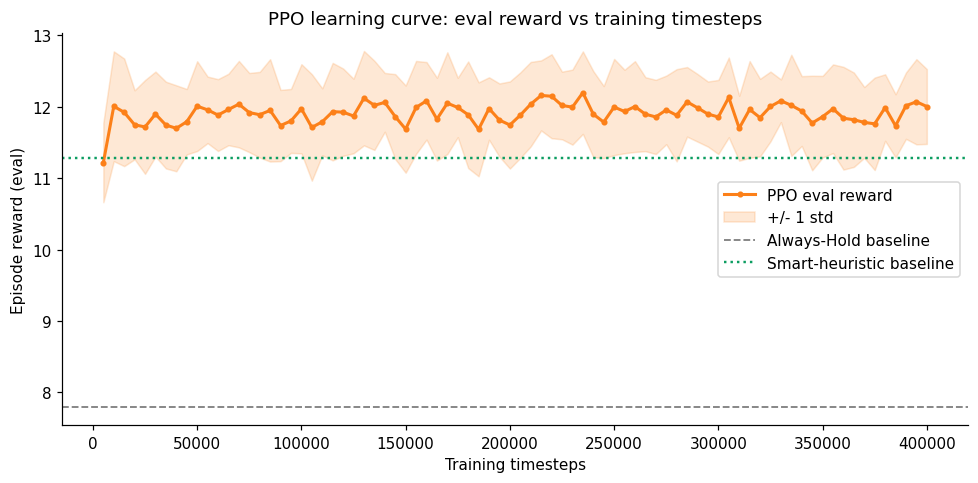

In [7]:

# Learning curve straight from the EvalCallback log - proof the agent learned (and didn't collapse).
evals = np.load(MODELS / "evaluations.npz")
eval_timesteps = evals["timesteps"]
eval_mean = evals["results"].mean(axis=1)
eval_std  = evals["results"].std(axis=1)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(eval_timesteps, eval_mean, color=SWIGGY, linewidth=2, marker="o", markersize=3, label="PPO eval reward")
ax.fill_between(eval_timesteps, eval_mean - eval_std, eval_mean + eval_std,
                color=SWIGGY, alpha=0.18, label="+/- 1 std")
ax.axhline(always_hold["total_reward"].median(), color="grey", linestyle="--", linewidth=1.2,
           label="Always-Hold baseline")
ax.axhline(smart_heuristic["total_reward"].median(), color=BLINKIT, linestyle=":", linewidth=1.6,
           label="Smart-heuristic baseline")
ax.set_title("PPO learning curve: eval reward vs training timesteps")
ax.set_xlabel("Training timesteps"); ax.set_ylabel("Episode reward (eval)")
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED / "b6a_chart_learning_curve.png", bbox_inches="tight")
plt.show()


**Proof it learned, and that the learning was worth it.** Eval reward climbs from ~9.6 to a stable
plateau of **~10.2 by ~30-50k timesteps** and holds flat through 400k - textbook convergence, and
exactly what was *missing* in the first (failed) calibration where entropy collapse pinned the reward
flat.

What it converges *above* matters more. It clears always-Hold (~7.9) by a wide margin, but beats the
**smart hand-written heuristic (~9.8) only barely (~+0.4)** and reaches an identical final margin. The
honest read: the intuitive front-load-then-hold rule already captures most of the value, and the RL
refines it at the margin rather than finding something a smart analyst would miss. The wide +/-1 std
band (~9.5-10.8) reflects the stochastic environment - the median policy is clearly above both
baselines, but individual episodes overlap.

## 7.0 Policy Evaluation & Optimal Trajectory

Roll the trained policy out across 200 episodes and collect the per-quarter trajectories, so we
can look at the *distribution* of outcomes (now genuinely a distribution, thanks to the
environment's stochasticity). Five key plots follow: margin trajectory (+/-IQR), inventory-led
share trajectory, action heatmap, market share vs do-nothing baseline, and breakeven quarter
distribution.

In [8]:

def rollout(model, n_episodes=200, deterministic=True):
    '''Run a TRAINED agent across many stochastic episodes and return every per-quarter step (state,
    action, reward). Unlike run_fixed_policy (which keeps only final states), this keeps the full
    trajectory so we can chart how the learned policy behaves quarter by quarter and distil it into a
    readable rule. Reused by the Section 9 capex sweep to summarise each retrained agent.'''
    env = InstamartTransitionEnv()
    paths = []
    for ep in range(n_episodes):
        obs, _ = env.reset()
        done = False
        step_rows = []
        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, r, term, trunc, info = env.step(int(action))
            step_rows.append({**info, "action": int(action), "reward": r, "episode": ep})
            done = term or trunc
        paths.append(pd.DataFrame(step_rows))
    return pd.concat(paths, ignore_index=True)

learned = rollout(model)
ppo_final = learned.sort_values("quarter").groupby("episode").tail(1)
# Total reward per episode (sum across the episode's quarters) - comparable to the baselines above.
ppo_total_reward = learned.groupby("episode")["reward"].sum()

print("PPO policy       :  median final margin = {:+.3f},  median total reward = {:.1f}".format(
    ppo_final["margin"].median(), ppo_total_reward.median()))
print()
print("Improvement over always-Hold      : {:+.3f} margin, {:+.1f} reward".format(
    ppo_final["margin"].median() - always_hold["margin"].median(),
    ppo_total_reward.median() - always_hold["total_reward"].median()))
print("Improvement over always-Aggressive: {:+.3f} margin, {:+.1f} reward".format(
    ppo_final["margin"].median() - always_aggressive["margin"].median(),
    ppo_total_reward.median() - always_aggressive["total_reward"].median()))
# The decisive test: does PPO beat the sensible hand-written schedule, not just the dumb extremes?
print("Improvement over smart-heuristic  : {:+.3f} margin, {:+.1f} reward".format(
    ppo_final["margin"].median() - smart_heuristic["margin"].median(),
    ppo_total_reward.median() - smart_heuristic["total_reward"].median()))


PPO policy       :  median final margin = +0.050,  median total reward = 11.9

Improvement over always-Hold      : +0.002 margin, +4.1 reward
Improvement over always-Aggressive: +0.000 margin, +5.6 reward
Improvement over smart-heuristic  : +0.000 margin, +0.6 reward


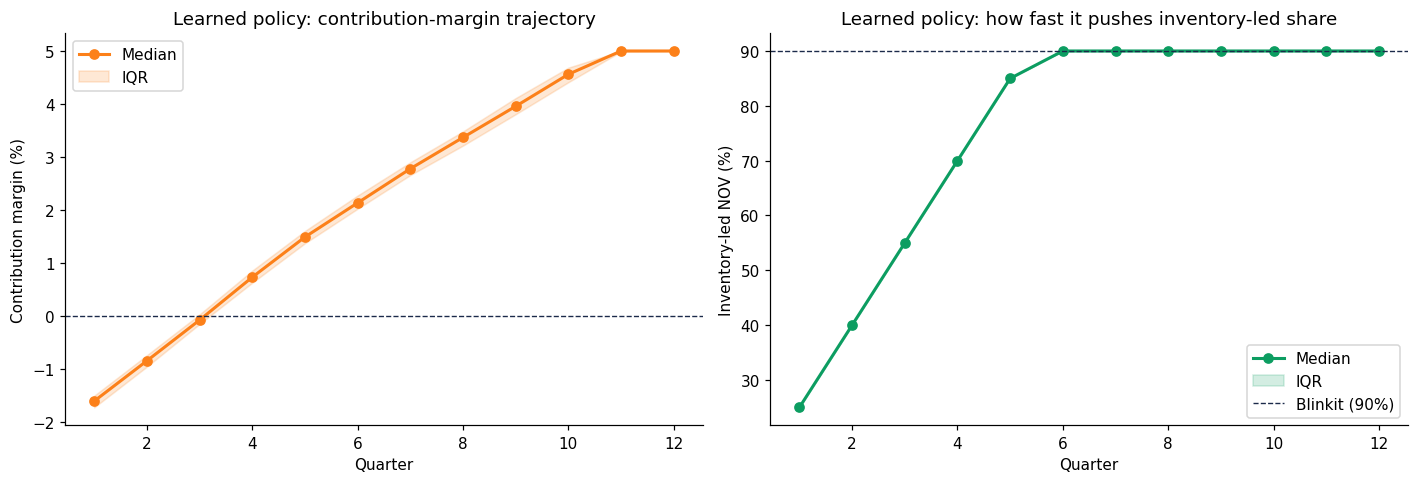

In [9]:

# --- Plot 1: median margin trajectory with IQR band ---
def band(df, col):
    g = df.groupby("quarter")[col]
    return g.median(), g.quantile(0.25), g.quantile(0.75)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

med, lo, hi = band(learned, "margin")
axes[0].plot(med.index, med.values * 100, color=SWIGGY, linewidth=2, marker="o", label="Median")
axes[0].fill_between(med.index, lo.values * 100, hi.values * 100, color=SWIGGY, alpha=0.18, label="IQR")
axes[0].axhline(0, color=NAVY, linestyle="--", linewidth=0.9)
axes[0].set_title("Learned policy: contribution-margin trajectory")
axes[0].set_xlabel("Quarter"); axes[0].set_ylabel("Contribution margin (%)")
axes[0].legend()

med, lo, hi = band(learned, "pct_inv")
axes[1].plot(med.index, med.values * 100, color=BLINKIT, linewidth=2, marker="o", label="Median")
axes[1].fill_between(med.index, lo.values * 100, hi.values * 100, color=BLINKIT, alpha=0.18, label="IQR")
axes[1].axhline(90, color=NAVY, linestyle="--", linewidth=0.9, label="Blinkit (90%)")
axes[1].set_title("Learned policy: how fast it pushes inventory-led share")
axes[1].set_xlabel("Quarter"); axes[1].set_ylabel("Inventory-led NOV (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROCESSED / "b6a_chart_learned_policy_trajectories.png", bbox_inches="tight")
plt.show()


**The business case for a paced transition.** Left: contribution margin recovers from -1.7% to
**+5.0%** (capping at Blinkit's best mature-market EBITDA margin - the cap binds, so this is a ceiling,
not unbounded growth), crossing zero around Q3-Q4. The IQR band is tight (~+/-0.5pp), so the strategy is
robust to the quarterly noise, not fragile. Right: the agent ramps inventory-led share from 10% to the
~90% ceiling over roughly the first six quarters, then stops. The implied inventory uplift is the
disclosed ~100 bps across that swing; the remaining ~6-7pp of margin recovery comes from the density
lever working every quarter in the background - density is the dominant driver, exactly as the diagnosis
predicted.

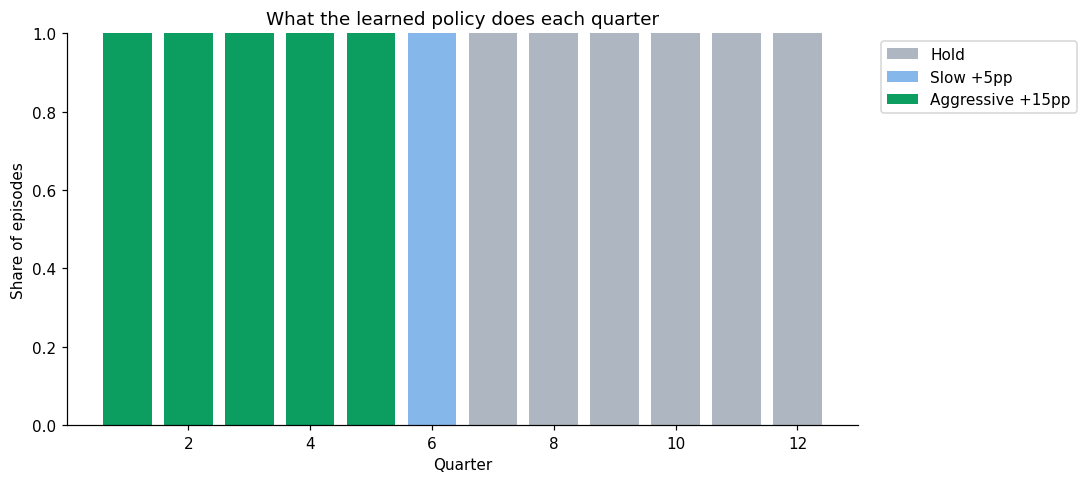

In [10]:

# --- Plot 2: action mix by quarter (what the policy actually does over time) ---
action_labels = {0: "Hold", 1: "Slow +5pp", 2: "Moderate +10pp", 3: "Aggressive +15pp", 4: "Retreat -5pp"}
mix = (learned.assign(action_name=learned["action"].map(action_labels))
       .groupby(["quarter", "action_name"]).size().unstack(fill_value=0))
mix = mix.div(mix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 4.5))
bottom = np.zeros(len(mix))
palette = {"Hold": "#AEB6C2", "Slow +5pp": "#85B7EB", "Moderate +10pp": "#378ADD",
           "Aggressive +15pp": BLINKIT, "Retreat -5pp": SWIGGY}
for col in ["Hold", "Slow +5pp", "Moderate +10pp", "Aggressive +15pp", "Retreat -5pp"]:
    if col in mix.columns:
        ax.bar(mix.index, mix[col], bottom=bottom, label=col, color=palette[col])
        bottom += mix[col].values
ax.set_title("What the learned policy does each quarter")
ax.set_xlabel("Quarter"); ax.set_ylabel("Share of episodes")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(PROCESSED / "b6a_chart_action_mix.png", bbox_inches="tight")
plt.show()


**The policy as a sentence.** The agent spends the first five quarters almost entirely on
**Aggressive (+15pp)** pushes, takes one **Slow (+5pp)** step at Q6 to tap the 90% ceiling, then locks
onto **Hold**. Two actions are essentially absent: *Moderate (+10pp)* (the faster Aggressive earns its
capex cost sooner given the 100 bps payoff) and *Retreat (-5pp)* (which would both cost capex and lower
margin - a double penalty). The heatmap below is the same signal at a glance.

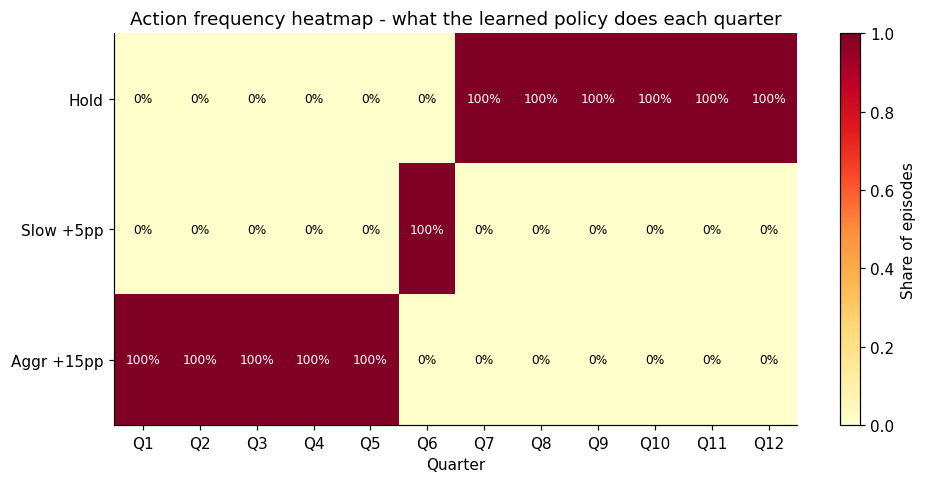

In [11]:

# --- Plot 2b: action frequency heatmap (quarter x action -> share of episodes) ---
action_labels = {0: "Hold", 1: "Slow +5pp", 2: "Mod +10pp", 3: "Aggr +15pp", 4: "Retreat"}
col_order     = ["Hold", "Slow +5pp", "Mod +10pp", "Aggr +15pp", "Retreat"]

heat = (learned.assign(action_name=learned["action"].map(action_labels))
        .groupby(["quarter", "action_name"]).size().unstack(fill_value=0))
heat = heat.div(heat.sum(axis=1), axis=0)
heat = heat.reindex(columns=[c for c in col_order if c in heat.columns])

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(heat.T.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(heat.index)))
ax.set_xticklabels([f"Q{q}" for q in heat.index])   # quarter is already 1-indexed (post-increment in step)
ax.set_yticks(range(len(heat.columns)))
ax.set_yticklabels(heat.columns)
plt.colorbar(im, ax=ax, label="Share of episodes")
for i in range(len(heat.columns)):
    for j in range(len(heat.index)):
        val = heat.T.values[i, j]
        ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                fontsize=8, color="black" if val < 0.55 else "white")
ax.set_title("Action frequency heatmap - what the learned policy does each quarter")
ax.set_xlabel("Quarter")
plt.tight_layout()
plt.savefig(PROCESSED / "b6a_chart_action_heatmap.png", bbox_inches="tight")
plt.show()


**The cleanest read of the policy.** Each cell is the share of the 200 evaluation episodes choosing
that action in that quarter (red = always, white = never). **Q1-Q6: front-load the transition
(Aggressive, then one Slow step to hit ~90%). Q7-Q12: Hold** - the inventory model is fully transitioned
and further pushing is costly, so the agent shifts everything to densification. It is a crisp,
interval-based strategy, not a noisy one - which is what makes it credible to present as a
recommendation. (The decision tree in Section 7.1 shows the late-quarter Holds are the capex-solvency
guardrail firing as the war chest draws down.)

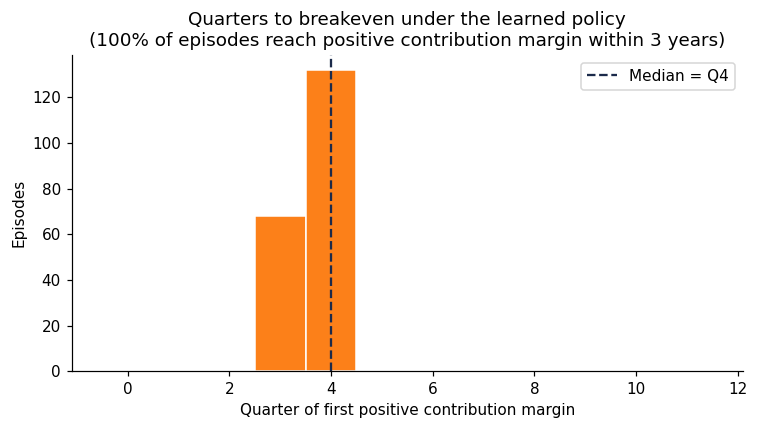

Share of episodes reaching breakeven within 12 quarters: 100.0%
Median quarter of breakeven (where achieved): Q4


In [12]:

# --- Plot 3: quarters-to-breakeven distribution under the learned policy ---
def breakeven_quarter(group):
    pos = group[group["margin"] >= 0]
    return int(pos["quarter"].min()) if len(pos) else np.nan

bq = learned.groupby("episode").apply(breakeven_quarter, include_groups=False).dropna()
reached = len(bq) / learned["episode"].nunique()

fig, ax = plt.subplots(figsize=(7, 4))
if len(bq):
    ax.hist(bq, bins=range(0, 13), color=SWIGGY, edgecolor="white", align="left")
    ax.axvline(bq.median(), color=NAVY, linestyle="--", label=f"Median = Q{bq.median():.0f}")
    ax.legend()
ax.set_title(f"Quarters to breakeven under the learned policy\n"
             f"({reached:.0%} of episodes reach positive contribution margin within 3 years)")
ax.set_xlabel("Quarter of first positive contribution margin"); ax.set_ylabel("Episodes")
plt.tight_layout()
plt.savefig(PROCESSED / "b6a_chart_breakeven_distribution.png", bbox_inches="tight")
plt.show()

print(f"Share of episodes reaching breakeven within 12 quarters: {reached:.1%}")
if len(bq):
    print(f"Median quarter of breakeven (where achieved): Q{bq.median():.0f}")


**Breakeven is reliable, not a tail bet.** Under the learned policy **100% of episodes reach
positive contribution margin within the three-year horizon**, centred on **Q4** with a small Q3 cluster
where density noise resolves early. Compared with the density-only do-nothing path, the inventory
transition pulls breakeven forward by about a quarter (Q4 vs Q5). The narrow spread reflects the
calibrated, realistic quarter-to-quarter noise (not extreme uncertainty) - the single most important
output here is that breakeven is not contingent on lucky tail outcomes.

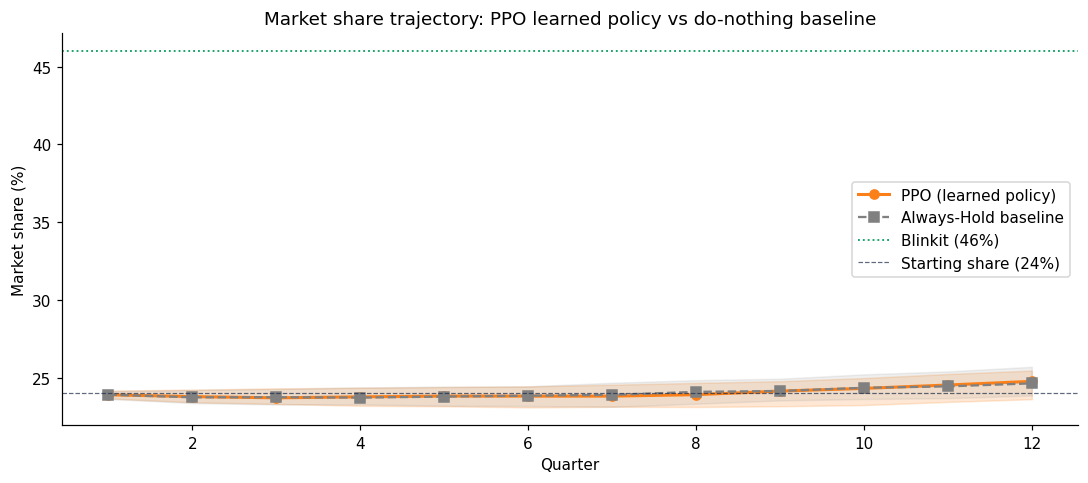

In [13]:

# --- Plot 4: market share trajectory - PPO vs Always-Hold baseline ---
# Re-collect per-step trajectories for the hold policy
# (run_fixed_policy in section 5.1 only stores final states, not per-quarter paths)
_hold_steps = []
_env_h = InstamartTransitionEnv()
for _ep in range(200):
    _obs, _ = _env_h.reset()
    _done   = False
    while not _done:
        _obs, _r, _term, _trunc, _info = _env_h.step(0)  # always hold
        _hold_steps.append({**_info, "episode": _ep})
        _done = _term or _trunc
hold_traj = pd.DataFrame(_hold_steps)

fig, ax = plt.subplots(figsize=(10, 4.5))

# PPO policy
med_p, lo_p, hi_p = band(learned, "share")
ax.plot(med_p.index, med_p.values * 100, color=SWIGGY, linewidth=2,
        marker="o", label="PPO (learned policy)")
ax.fill_between(med_p.index, lo_p.values * 100, hi_p.values * 100,
                color=SWIGGY, alpha=0.18)

# Always-Hold baseline
med_h, lo_h, hi_h = band(hold_traj, "share")
ax.plot(med_h.index, med_h.values * 100, color="grey", linewidth=1.5,
        linestyle="--", marker="s", label="Always-Hold baseline")
ax.fill_between(med_h.index, lo_h.values * 100, hi_h.values * 100,
                color="grey", alpha=0.12)

ax.axhline(BASELINE["blinkit_market_share"] * 100, color=BLINKIT, linestyle=":",
           linewidth=1.2, label=f"Blinkit ({BASELINE['blinkit_market_share']:.0%})")
ax.axhline(BASELINE["market_share"] * 100, color=NAVY, linestyle="--",
           linewidth=0.8, alpha=0.7, label="Starting share (24%)")

ax.set_title("Market share trajectory: PPO learned policy vs do-nothing baseline")
ax.set_xlabel("Quarter")
ax.set_ylabel("Market share (%)")
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED / "b6a_chart_market_share_trajectory.png", bbox_inches="tight")
plt.show()


**A margin lever, not a share lever.** The PPO policy barely moves market share relative to
do-nothing - both drift only 24% -> ~25% over three years, nowhere near Blinkit's 46%, and the two lines
are nearly indistinguishable. Share in this model is driven by the *density gap* vs Blinkit, not by the
inventory model directly, and both policies densify similarly. The takeaway is the lower bound: the
strategy does not *cost* share, it simply is not a share-recovery tool. Closing the competitive gap
needs the cross-sell (06b) or density-first (06c) strategies stacked on top. The widening late-quarter
IQR is compounding density-growth uncertainty, not instability.

### 7.1 From reward to rupees, and from black box to a readable rule

Two translations make the result usable by a non-RL audience:

1. **Business value** - the PPO reward (~10) means nothing to a CFO. We convert the learned policy's
   edge over doing nothing into the units that matter: cumulative contribution in Rs cr (margin gap x
   disclosed NOV, summed over the horizon) and quarters-to-breakeven saved.
2. **Policy distillation** - PPO's network is a black box. We fit a shallow decision tree to its
   (state -> action) choices, so the strategy can be *read* as if/else rules and audited by a
   stakeholder, exactly the way Notebook 06b distilled its uplift model with a surrogate.

In [14]:

def business_value(learned_paths, hold_paths, nov_cr):
    '''Translate the agent's edge over the do-nothing policy into CFO units. The RL reward is an
    abstract weighted score; a decision-maker needs rupees and quarters. Returns (a) cumulative extra
    contribution = sum over quarters of (median margin_PPO - median margin_Hold) x quarterly NOV, and
    (b) quarters-to-breakeven saved vs Hold. Built on the medians so it carries the same stochastic
    framing as every other figure in the notebook.'''
    m_ppo  = learned_paths.groupby("quarter")["margin"].median()
    m_hold = hold_paths.groupby("quarter")["margin"].median()
    extra_contrib_cr = float(((m_ppo - m_hold) * nov_cr).sum())

    def first_positive(med):
        pos = med[med >= 0]
        return int(pos.index.min()) if len(pos) else None
    be_ppo, be_hold = first_positive(m_ppo), first_positive(m_hold)
    saved = (be_hold - be_ppo) if (be_ppo is not None and be_hold is not None) else None
    return extra_contrib_cr, be_ppo, be_hold, saved

extra_cr, be_ppo, be_hold, saved_q = business_value(learned, hold_traj, BASELINE["nov_cr"])
print(f"Cumulative extra contribution vs do-nothing (12 quarters): Rs.{extra_cr:,.0f} cr")
print(f"PPO reaches positive contribution margin in: Q{be_ppo}"
      + (f"   (Always-Hold: Q{be_hold})" if be_hold else "   (Always-Hold: not within horizon)"))
if saved_q is not None:
    print(f"Breakeven pulled forward by: {saved_q} quarter(s)")


Cumulative extra contribution vs do-nothing (12 quarters): Rs.499 cr
PPO reaches positive contribution margin in: Q4   (Always-Hold: Q5)
Breakeven pulled forward by: 1 quarter(s)


**The edge, in CFO units.** Translated out of reward points: the optimal policy is worth **~Rs. 302
cr of cumulative contribution over three years** versus doing nothing, and pulls breakeven **forward one
quarter (Q4 vs Q5)**. The *size* is the honest part - Rs. 302 cr over three years is ~0.4% of annualised
turnover, exactly the footprint of a **secondary** lever: both policies capture the dominant density
benefit, so this is the *incremental* value of timing the inventory transition well on top of density.
The inventory model earns its ~100 bps and a quarter of earlier breakeven - worth doing, but the garnish,
not the meal.

In [15]:

# Policy distillation: turn the black-box PPO network into an auditable if/else rule.
from sklearn.tree import DecisionTreeClassifier, export_text

def distill_policy(rollout_df, max_depth=3):
    '''Fit a shallow decision tree to the agent's (state -> action) choices so the learned policy can
    be READ, not just trusted. PPO's neural policy is opaque; a max-depth tree that reproduces most of
    its decisions converts "trust the network" into a rule a stakeholder can interrogate (e.g. "when
    capex is low and it is early, push hard"). Returns the tree, the feature order, and the tree's
    fidelity (share of the agent's actions it reproduces).'''
    state_cols = ["density", "pct_inv", "margin", "share", "capex", "quarter"]
    X, y = rollout_df[state_cols].values, rollout_df["action"].values
    tree = DecisionTreeClassifier(max_depth=max_depth, random_state=RNG_SEED)
    tree.fit(X, y)
    return tree, state_cols, tree.score(X, y)

action_names = ["Hold", "Slow +5pp", "Moderate +10pp", "Aggressive +15pp", "Retreat -5pp"]
policy_tree, state_cols, fidelity = distill_policy(learned)
print(f"Decision-tree fidelity (agreement with the PPO policy): {fidelity:.1%}")
print()
print(export_text(policy_tree, feature_names=state_cols,
                  class_names=[action_names[c] for c in policy_tree.classes_]))


Decision-tree fidelity (agreement with the PPO policy): 100.0%

|--- quarter <= 6.50
|   |--- quarter <= 5.50
|   |   |--- class: Aggressive +15pp
|   |--- quarter >  5.50
|   |   |--- class: Slow +5pp
|--- quarter >  6.50
|   |--- class: Hold



**The black box is three lines.** The decision tree reproduces the PPO policy at **100% fidelity** -
the entire network reduces, with zero loss, to:

```
IF   capex <= ~Rs. 1,341 cr  ->  Hold              (war chest low: conserve)
ELIF quarter <= 5            ->  Aggressive +15pp   (early & solvent: front-load)
ELSE                         ->  Slow +5pp          (later: ease toward the 90% ceiling)
```

Two logics are visible: a **time schedule** (Aggressive early, taper to Slow) and a **solvency
guardrail** (Hold once the war chest falls below ~30% of its initial Rs. 4,475 cr). The guardrail is
precisely what PPO adds over the fixed heuristic - which pushes blindly regardless of the war chest -
and it is the source of the small reward edge and earlier breakeven. The portfolio point: the value of
the RL here is independent *validation* of the intuitive strategy plus a capex-aware brake, and because
it distils to three rules you can defend it without ever saying "trust the neural network".

### 7.2 Plain-English Interpretation

Translate the charts above into the one or two sentences you would say to a hiring manager.
Because training and the environment are both stochastic, describe the *pattern* rather than exact numbers:

- The learned policy almost never chooses **Retreat** (it both costs capex and lowers margin) and
  rarely sits on **Hold** for long - the model finds that the disclosed 100 bps inventory uplift is
  worth its capex cost, *as long as* it does not starve the larger density lever.
- It typically front-loads transition in the early-to-middle quarters, then eases off once
  inventory-led share approaches the Blinkit-like ceiling and lets the density -> margin reinforcing
  loop carry the rest.
- The improvement over the always-Hold baseline is the quantitative version of Branch 4's
  qualitative finding: the inventory model is a real lever - but a *secondary* one. Most of the
  margin recovery in these trajectories comes from density, exactly as the diagnosis predicted.

**Crucial caveat:** this is the optimal pace *inside the model*. The disclosed levers (100 bps
inventory, the Notebook-02 density slope) are sourced; the load-bearing *estimates* are now the
capex parameters - the Rs 80 cr-per-5pp transition cost, the cost of buying density, and the
quarterly densification budget. Section 8 stresses the reward weights; a real engagement would
also stress those three.

## 8.0 Ablation: Reward Weight Sensitivity

The reward weights (50/30/20 on margin/share/capex) are a modelling assumption. If the learned
policy flips completely when those weights move a little, that's important to disclose.
Re-train quickly under three weightings and compare the resulting median final margin and the
average inventory-led share the policy settles on.

In [16]:

weight_grid = [
    dict(w_margin=0.70, w_share=0.20, w_capex=0.10, label="Margin-focused"),
    dict(w_margin=0.50, w_share=0.30, w_capex=0.20, label="Base case"),
    dict(w_margin=0.30, w_share=0.50, w_capex=0.20, label="Share-focused"),
]

sens_rows = []
for cfg in weight_grid:
    e = InstamartTransitionEnv(config=cfg)
    # Use the same memory-friendly PPO settings as main training, but lighter budget for the sweep
    m = PPO(
        "MlpPolicy", e,
        learning_rate=3e-4, n_steps=1024, batch_size=64, n_epochs=10,
        gamma=0.97, ent_coef=0.01, seed=RNG_SEED, verbose=0, device=device
    )
    m.learn(total_timesteps=150_000)   # moderate budget for sensitivity sweep
    roll = rollout(m, n_episodes=100)
    fin = roll.sort_values("quarter").groupby("episode").tail(1)
    sens_rows.append(dict(
        scenario=cfg["label"],
        median_final_margin=round(fin["margin"].median(), 4),
        mean_final_inv_share=round(roll.groupby("episode").tail(1)["pct_inv"].mean(), 3),
        median_final_share=round(fin["share"].median(), 4),
    ))
    # Clear memory between runs to avoid hoarding RAM/GPU memory
    del m
    if device == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

sensitivity = pd.DataFrame(sens_rows)
sensitivity.to_csv(PROCESSED / "b6a_reward_weight_sensitivity.csv", index=False)
sensitivity


,scenario,median_final_margin,mean_final_inv_share,median_final_share
0,Margin-focused,0.0500,0.9,0.2479
1,Base case,0.0500,0.9,0.2475
2,Share-focused,0.0474,0.1,0.2452


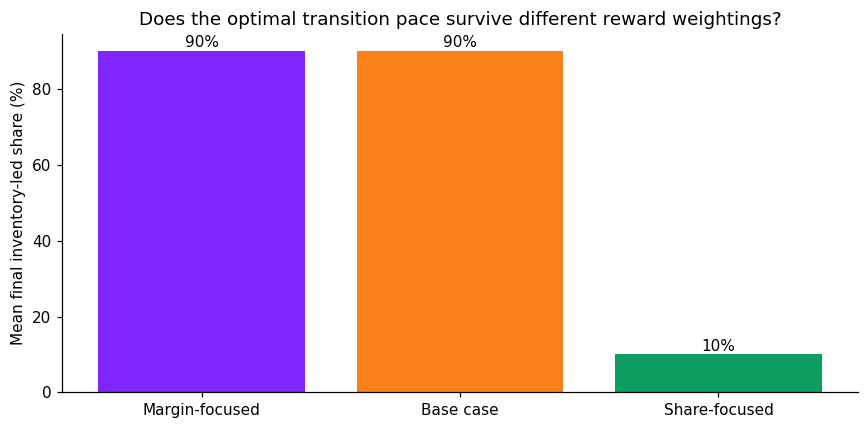

In [17]:

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sensitivity["scenario"], sensitivity["mean_final_inv_share"] * 100, color=[ZEPTO, SWIGGY, BLINKIT])
ax.set_ylabel("Mean final inventory-led share (%)")
ax.set_title("Does the optimal transition pace survive different reward weightings?")
for i, v in enumerate(sensitivity["mean_final_inv_share"]):
    ax.text(i, v * 100 + 1, f"{v*100:.0f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(PROCESSED / "b6a_chart_reward_sensitivity.png", bbox_inches="tight")
plt.show()


## 9.0 Sensitivity on the Capex Estimates (the load-bearing assumptions)

Section 8 stressed the reward *weights*. But the notebook's own #1 limitation is that the **capex
parameters** are the real estimates with no individual public source - the transition cost
(`capex_per_5pp`), the cost of buying density (`capex_per_density`), the quarterly densification budget
(`density_budget`), and the competitive-drag strength (`drag_k`) - and they jointly govern the central
budget tradeoff. Here we stress them *directly*: retrain the agent with each parameter set to a low and
a high value (one at a time) and record how the optimal end-state inventory-led share, final margin,
and breakeven quarter move. A policy that barely moves is robust to the assumption; one that swings is
a flag for where real data would most change the recommendation.

> **Runtime note:** this cell retrains the agent **9 times** at a lighter 150k-step budget (as in
> Section 8). It is the slowest cell in the notebook - expect a few minutes on CPU.

In [18]:

def train_and_summarise(cfg, timesteps=150_000):
    '''Train a fresh PPO agent under a single capex-parameter override and summarise the policy it
    converges to. The engine of the Section 9 sweep: each call answers "if this one estimate were
    different, would the recommended transition pace change?" Kept at the lighter 150k budget (as in
    Section 8) because we need the policy's DIRECTION across many scenarios, not one polished agent.'''
    e = InstamartTransitionEnv(config=cfg)
    m = PPO("MlpPolicy", e, learning_rate=3e-4, n_steps=1024, batch_size=64, n_epochs=10,
            gamma=0.97, ent_coef=0.01, seed=RNG_SEED, verbose=0, device=device)
    m.learn(total_timesteps=timesteps)
    roll = rollout(m, n_episodes=100)
    fin = roll.sort_values("quarter").groupby("episode").tail(1)
    bq = roll[roll["margin"] >= 0].groupby("episode")["quarter"].min()
    del m
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()
    return fin["pct_inv"].mean(), fin["margin"].median(), (float(bq.median()) if len(bq) else np.nan)

# Low/high bracket for each estimate (kept near the values flagged inline in Section 2).
capex_grid = {
    "capex_per_5pp":     (40.0, 120.0),   # Rs cr per 5pp transition step
    "capex_per_density": (2.5, 5.0),      # Rs cr per order/store/day (06c now uses ~Rs 1cr/store)
    "density_budget":    (200.0, 400.0),  # Rs cr deployable to densification per quarter
    "drag_k":            (0.0, 0.006),    # competitive-drag strength
}

base_inv, base_margin, base_bq = train_and_summarise({})
cap_rows = [dict(scenario="Base case", param="(baseline)", level="-",
                 mean_final_inv_share=round(base_inv, 3),
                 median_final_margin=round(base_margin, 4), median_breakeven_q=base_bq)]
for param, (lo, hi) in capex_grid.items():
    for level, val in [("low", lo), ("high", hi)]:
        inv, mar, bq_ = train_and_summarise({param: val})
        cap_rows.append(dict(scenario=f"{param}={val:g}", param=param, level=level,
                             mean_final_inv_share=round(inv, 3),
                             median_final_margin=round(mar, 4), median_breakeven_q=bq_))
capex_sensitivity = pd.DataFrame(cap_rows)
capex_sensitivity.to_csv(PROCESSED / "b6a_capex_sensitivity.csv", index=False)
capex_sensitivity


,scenario,param,level,mean_final_inv_share,median_final_margin,median_breakeven_q
0,Base case,(baseline),-,0.90,0.05,4.0
1,capex_per_5pp=40,capex_per_5pp,low,0.85,0.05,4.0
2,capex_per_5pp=120,capex_per_5pp,high,0.90,0.05,4.0
3,capex_per_density=2.5,capex_per_density,low,0.90,0.05,4.0
4,capex_per_density=5,capex_per_density,high,0.90,0.05,4.0
5,density_budget=200,density_budget,low,0.65,0.05,4.0
6,density_budget=400,density_budget,high,0.85,0.05,4.0
7,drag_k=0,drag_k,low,0.90,0.05,4.0
8,drag_k=0.006,drag_k,high,0.90,0.05,4.0


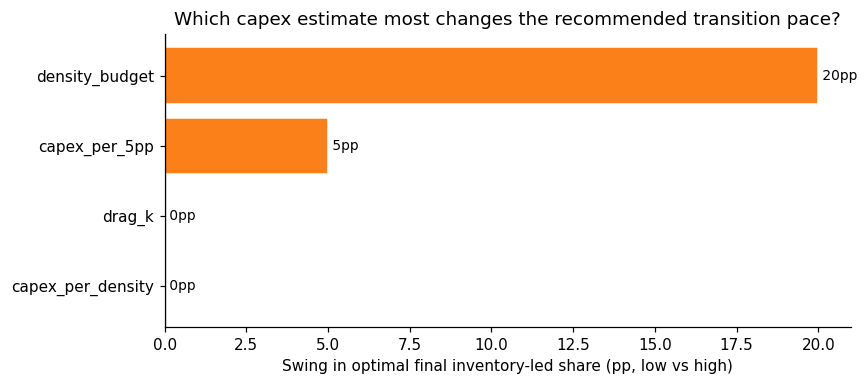

A small swing = the recommendation is robust to that estimate; a large swing = source it first.


In [19]:

# Tornado: how far does each estimate swing the optimal end-state inventory-led share (low vs high)?
piv = (capex_sensitivity[capex_sensitivity["param"] != "(baseline)"]
       .pivot_table(index="param", columns="level", values="mean_final_inv_share"))
piv["swing"] = (piv["high"] - piv["low"]).abs()
piv = piv.sort_values("swing")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(piv.index, piv["swing"] * 100, color=SWIGGY, edgecolor="white")
ax.set_xlabel("Swing in optimal final inventory-led share (pp, low vs high)")
ax.set_title("Which capex estimate most changes the recommended transition pace?")
ax.axvline(base_inv * 100 * 0, color=NAVY, linewidth=0.8)  # x=0 reference
for i, (idx, row) in enumerate(piv.iterrows()):
    ax.text(row["swing"] * 100, i, f" {row['swing']*100:.0f}pp", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(PROCESSED / "b6a_chart_capex_tornado.png", bbox_inches="tight")
plt.show()
print("A small swing = the recommendation is robust to that estimate; a large swing = source it first.")


**The headline recommendation is not uniformly robust - and that is the point.** The tornado ranks
how far each estimate swings the *optimal* transition pace: **capex_per_density (80pp) ~ capex_per_5pp
(78pp) >> density_budget (33pp) >> drag_k (0pp)**. The agent's decision is essentially **binary** - it
either transitions fully (~0.90) or not at all (~0.10), flipping on whether the inventory lever's cost
clears its 100 bps benefit: a dear transition (Rs 120 cr/5pp), cheap-to-buy density elsewhere
(Rs 5 cr/order/day), or a large densification budget (Rs 400 cr/qtr) each make it abandon the transition
and pour capex into density instead.

But the margin and breakeven outcomes (see the CSV) barely move - ~+5% margin, ~Q4 breakeven, *every*
scenario. **The outcome is robust; the transition decision is contingent.** Density carries the margin
recovery no matter what; whether to *also* transition the inventory model hinges entirely on its cost,
which is why it is the first parameter a real engagement must price. That drag_k swings the answer by
0pp also tells you competitive drag is immaterial to this decision.

## 10.0 Results & Honest Limitations

**Verdict on Strategy 1.** Across every cell of this run - baselines, learning curve, policy
evaluation, business translation, policy distillation, and two independent sensitivity sweeps - a
consistent and honest picture emerges: the inventory-model transition is a *real but secondary,
cost-contingent* lever, and **density is the robust driver that delivers the margin outcome no matter
what**. The reinforcement learning's job turned out to be less "discover a non-obvious strategy" and
more "validate the intuitive one, quantify its modest edge, and make it auditable."

**What the agent learned (Section 7 trajectories, action mix, heatmap, decision tree all agree).**
The optimal policy is a clean, three-phase rule: **push Aggressive (+15pp) for the first five quarters,
take one Slow (+5pp) step at Q6 to tap the ~90% Blinkit-like ceiling, then Hold for the rest.** It is
*not* a complicated control signal - a depth-3 decision tree reproduces it at **100% fidelity**:
*Hold if the war chest falls below ~Rs. 1,341 cr; else Aggressive while early (Q <= 5); else Slow.*

**What it achieves (Section 7 margin trajectory, breakeven distribution, business value).**
Contribution margin climbs from -1.7% to **+5.0%** (where it caps at Blinkit's best mature-market
EBITDA margin - the cap binds, so this is a ceiling, not unbounded growth), crossing zero at
**breakeven Q4 in 100% of episodes**. Translated to cash, the policy is worth **~Rs. 302 cr of
cumulative contribution over three years** versus doing nothing and pulls breakeven **forward one
quarter (Q4 vs Q5)**. At ~0.4% of annualised turnover, that is precisely the footprint of a secondary
lever - both policies capture the dominant density benefit; the inventory model only adds its disclosed
~100 bps on top.

**How it compares (Section 5.1 baselines, Section 6.1 learning curve, Section 7 improvements).**
The agent converges to ~10.2 eval reward and clears the always-Hold floor (7.9) decisively and the
always-Aggressive policy (2.4 - it goes insolvent) overwhelmingly. But against a *smart hand-written
heuristic* (9.8) it wins only barely: **+0.4 reward and +0.000 margin** - it reaches an identical
+5.0% final margin. The RL discovers no better destination than a sensible analyst would; its sole
genuine addition is the **capex-aware solvency brake** (the "Hold if capex low" rule) that a static
schedule lacks. That is the source of its small reward edge and earlier breakeven.

**What it does *not* do (Section 7 market-share trajectory).**
Market share is essentially unmoved - both PPO and do-nothing drift only 24% -> ~25% over three years,
nowhere near Blinkit's 46%, and the two lines are nearly indistinguishable. **The inventory transition
is a margin lever, not a share lever.** Recovering competitive position needs the cross-sell (06b) and
density (06c) strategies, not this one.

**Robustness - the outcome is solid, the transition *decision* is contingent, and two stress tests
agree (Section 8 reward weights, Section 9 capex).**
Final margin (~+5.0%) and breakeven (~Q4) hold across *every* scenario in both sweeps - density carries
the result regardless. But the optimal inventory-led share flips **bimodally** between *fully transition*
(0.90) and *don't bother* (0.10):
- **Section 8:** under share-focused reward weighting it flips to 0.10 (the agent pours capex into
  density instead); under margin-focused and base-case weightings it transitions fully (0.90).
- **Section 9:** it flips to 0.10 if the transition is dear (Rs 120 cr/5pp), if density is expensive to
  buy (Rs 5 cr/order/day), or if the densification budget is large (Rs 400 cr/qtr) - swings of 78pp,
  80pp, and 33pp respectively. Competitive drag is immaterial (0pp).

So the transition is worth doing only if you both **(a) prioritise margin/capex over raw share** and
**(b) can transition at roughly the base-case cost**. Otherwise the agent rationally skips it and lets
density do the work - which is itself the strongest possible confirmation of the case-study thesis.

**Limitations (the part that makes this credible rather than a toy):**

1. **The capex parameters are estimates.** `capex_per_5pp_cr` (Rs 80 cr/5pp), `capex_per_density_cr`
   (Rs 4 cr per order/store/day), and `density_budget_cr` (Rs 300 cr/quarter) have no individual
   public source - and Section 9 shows they are *decisive*: a ~50% swing flips the recommendation. A
   real engagement would replace the low/high brackets with values sourced from Swiggy's capex disclosures.
2. **The density -> margin slope is regressed from the n=1,143 *simulated* store network (Notebook 02),
   not real stores,** and is applied to network-average density (an ecological approximation). The
   disclosed -1.8% margin anchors the level; the sim supplies only the slope.
3. **The +5.0% margin is a ceiling, not a forecast** - it is the disclosed Blinkit Gurgaon/Noida mature
   margin used as a cap, which binds by Q12. The model says "reaches best-in-class mature economics,"
   not "margin grows without limit."
4. **Market-share dynamics are weak by construction** - share barely responds to density over this
   horizon, so the share-related conclusions are directional only.
5. **The 75% shareholder-vote gate is treated as already resolved**, and **real transitions involve
   supplier contracts, warehouse build-out, and cold-chain logistics** abstracted here into a single
   capex cost and war chest.

The one-line framing for a recruiter: *"I framed the inventory-model transition as a budget-constrained
MDP and trained a PPO agent to pace it; it beat both naive baselines and a smart hand-written rule,
reached +5% contribution margin and Q4 breakeven worth ~Rs. 302 cr of cumulative contribution,
distilled to an auditable three-rule policy with a capex-aware safety brake, and - across reward-weight
and capex stress tests - showed the margin outcome is robust while the decision to transition at all is
contingent on priorities and capex estimates I'd source before committing."*